# Description: Evaluate m-NORDIC ability at removing Thermal Noise (Discovery Dataset)

Prior to using this notebook, you need to run the ```bash/S03_ThermalNoiseEstimation...``` script to estimate thermal noise in all scans and TEs from both datasets.

For each scan, this script will write two files:

* ```{sbj}_{ses}_task-rest_echo-{e}_bold.NORDIC_off.ThermalNoise.txt```: holds thermal noise estimates before applying m-NORDIC.
* ```{sbj}_{ses}_task-rest_echo-{e}_bold.NORDIC_on.ThermalNoise.txt```: holds thermal noise estimates after applying m-NORDIC.

Expectations:

* Thermal noise should be TE independent, yet becuase the suboptimal way in which we are measuring thermal noise, a slight difference migth occur.
* Thermal noise should be significantly smaller after m-NORDIC for all echoes.

In [9]:
import pandas as pd
import os.path as osp
import seaborn as sns
import numpy as np
from tqdm import tqdm
from utils.basics import PRCS_DATA_DIR
from statannotations.Annotator import Annotator
import matplotlib.pyplot as plt

from utils.basics import get_dataset_index

def set_fontsizes(fig, size=14):
    for ax in fig.axes:
        ax.title.set_fontsize(size)
        ax.xaxis.label.set_size(size)
        ax.yaxis.label.set_size(size)
        ax.tick_params(labelsize=size - 1)

        leg = ax.get_legend()
        if leg is not None:
            for t in leg.get_texts():
                t.set_fontsize(size - 1)
            if leg.get_title() is not None:
                leg.get_title().set_fontsize(size)



### First we define a list of subject IDs in the "evaluation" dataset, and also of session ids (e.g., cardiac or constant gated)

In [2]:
DATASET = 'discovery'
ds_index = get_dataset_index(DATASET)
ses_list = list(ds_index.get_level_values('Session').unique())
sbj_list = list(ds_index.get_level_values('Subject').unique())
dataset_info_df = pd.DataFrame(index=pd.MultiIndex.from_product([sbj_list,ses_list],names=['Subject','Session']))

++ Number of scans    = 14
++ Number of subjects = 7


### Next, we load the thermal noise estimates that were computed with ```/bash/S02_ThermalNoise_Estimation.<DATASET>.CreateSwarm.sh```

In [3]:
df_list = []
for sbj,ses in tqdm(dataset_info_df.index, desc='Scan'):
    for e in range(1,4):    
        aux_path = osp.join(PRCS_DATA_DIR,sbj,'D02_NORDIC',f'{sbj}_{ses}_task-rest_echo-{e}_bold.NORDIC_off.ThermalNoise.txt')
        aux      = np.loadtxt(aux_path)
        df_list.append( {'Subject':sbj,'Session':ses,'m-NORDIC':'off','Echo':e,'Thermal Noise':np.mean(aux[10::])})
        aux_path = osp.join(PRCS_DATA_DIR,sbj,'D02_NORDIC',f'{sbj}_{ses}_task-rest_echo-{e}_bold.NORDIC_on.ThermalNoise.txt')
        aux      = np.loadtxt(aux_path)
        df_list.append( {'Subject':sbj,'Session':ses,'m-NORDIC':'on','Echo':e,'Thermal Noise':np.mean(aux[10::])})
df = pd.DataFrame(df_list)

Scan: 100%|██████████| 14/14 [00:00<00:00, 257.89it/s]


### We then separate the data into two separate datasets (for plotting and stats purposes). One will contain the estimates for the cardiac_gated scans, and the other one for the constant_gated scans

In [4]:
df_ConstG = df.set_index('Session').loc['constant_gated'].copy().reset_index(drop=True)
df_CardG  = df.set_index('Session').loc['cardiac_gated'].copy().reset_index(drop=True)

### The next cell computes the mean and stdev of the reduction in thermal noise. We report these values in the manuscript

In [5]:
aux = (100 * (df.set_index(['Subject','Session','m-NORDIC','Echo']).loc[:,:,'off',:] - df.set_index(['Subject','Session','m-NORDIC','Echo']).loc[:,:,'on',:]) / df.set_index(['Subject','Session','m-NORDIC','Echo']).loc[:,:,'off',:]).describe()
print('Themal Noise reduction after m-NORDIC (%%): %0.2f +/- %0.2f' % (aux.loc['mean'].values[0],aux.loc['std'].values[0])) 

Themal Noise reduction after m-NORDIC (%): 31.61 +/- 4.30


### And now we generate Supplementary Figure 2.a

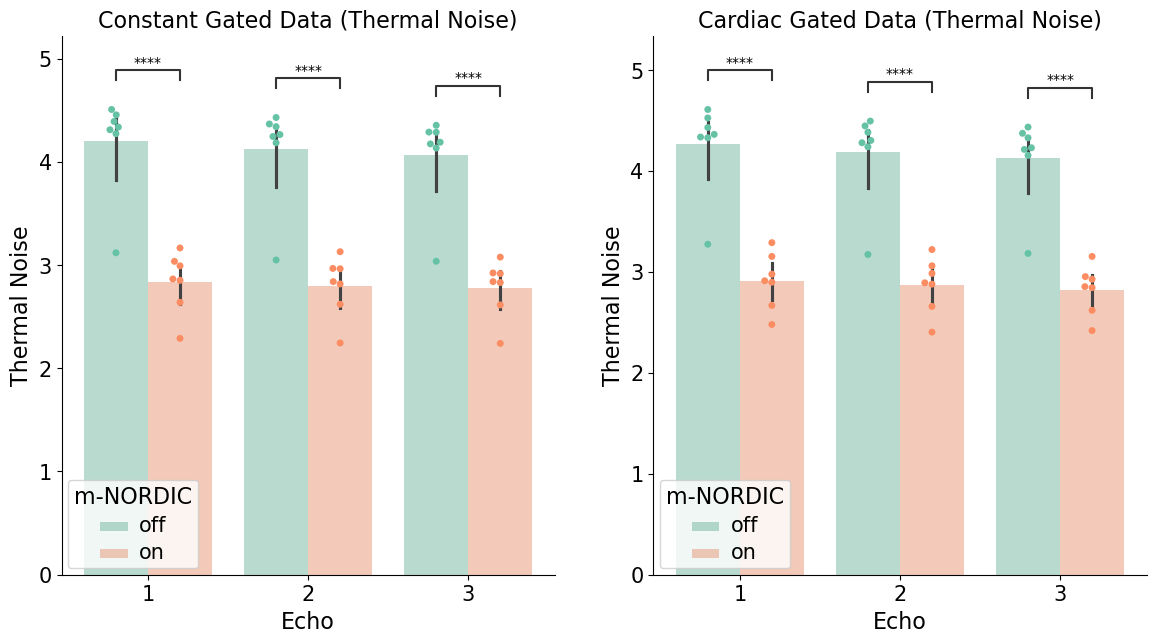

In [11]:
fig, axs = plt.subplots(1,2,figsize=(14,7))
# Results for Constant Gated
sns.barplot(  data=df_ConstG,hue='m-NORDIC',x='Echo',y='Thermal Noise', palette='Set2', errorbar='ci', ax=axs[0], alpha=0.5).set_title('Constant Gated Data (Thermal Noise)')
sns.swarmplot(data=df_ConstG,hue='m-NORDIC',x='Echo',y='Thermal Noise', palette='Set2',ax=axs[0], dodge=True, legend=False)
pairs=[((1,'off'),(1,'on')),((2,'off'),(2,'on')),((3,'off'),(3,'on'))]
annotation = Annotator(axs[0], pairs, data=df_ConstG, hue='m-NORDIC', y='Thermal Noise',x='Echo')
annotation.configure(test='t-test_paired', loc='inside', verbose=0, comparisons_correction="Bonferroni");
annotation.apply_test(alternative='two-sided');
annotation.annotate();
# Results for Cardiac Gated
sns.barplot(  data=df_CardG,hue='m-NORDIC',x='Echo',y='Thermal Noise', palette='Set2', errorbar='ci', ax=axs[1], alpha=0.5).set_title('Cardiac Gated Data (Thermal Noise)')
sns.swarmplot(data=df_CardG,hue='m-NORDIC',x='Echo',y='Thermal Noise', palette='Set2',ax=axs[1], dodge=True, legend=False)
sns.despine()
pairs=[((1,'off'),(1,'on')),((2,'off'),(2,'on')),((3,'off'),(3,'on'))]
annotation = Annotator(axs[1], pairs, data=df_CardG, hue='m-NORDIC', y='Thermal Noise',x='Echo')
annotation.configure(test='t-test_paired', loc='inside', verbose=0, comparisons_correction="Bonferroni");
annotation.apply_test(alternative='two-sided');
annotation.annotate();
set_fontsizes(fig, size=16);

In [12]:
fig.tight_layout()
fig.savefig('./figures/pBOLD_SuppFig02_a.png', bbox_inches="tight", pad_inches=0)